## One-Class SVM — Detection d'anomalies avec sklearn
### Dataset : local creditcard.csv, sinon telechargement automatique via Kaggle

In [18]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay
 )
import warnings
warnings.filterwarnings("ignore")

In [19]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\afagn\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [32]:
import os

# 1) Localisation du fichier CSV
csv_file = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_file)

# 2) Separation des classes
df_normal = df[df["Class"] == 0]
df_fraud = df[df["Class"] == 1]

# 3) Features (sans Time et Class)
features = df.columns.drop(["Time", "Class"])

# Split normal: train principal + validation normal
X_train_raw, X_val_normal_raw = train_test_split(
    df_normal[features], test_size=0.2, random_state=42
)

# Validation: normaux uniquement
X_val_raw = X_val_normal_raw
y_val = np.ones(len(X_val_raw), dtype=int)

# Test final: normaux restants + toutes les fraudes
X_test_raw = pd.concat([X_val_normal_raw, df_fraud[features]], ignore_index=True)
y_test = np.hstack([
    np.ones(len(X_val_normal_raw), dtype=int),
    -np.ones(len(df_fraud), dtype=int)
])

# 4) Standardisation
scaler = StandardScaler()
X_train_sc_full = scaler.fit_transform(X_train_raw)
X_val_sc = scaler.transform(X_val_raw)
X_test_sc_final = scaler.transform(X_test_raw)

print(f"Train (normaux)            : {X_train_sc_full.shape[0]}")
print(f"Validation (normaux)       : {X_val_sc.shape[0]}")
print(f"Test final (normaux+fraude): {X_test_sc_final.shape[0]}")

Train (normaux)            : 227452
Validation (normaux)       : 56863
Test final (normaux+fraude): 57355


In [33]:
# ENTRAINEMENT DU MODELE ONE-CLASS SVM (avec validation separee)

oc_svm = OneClassSVM(nu=0.05, kernel="rbf", gamma="scale")
oc_svm.fit(X_train_sc_full)

# Validation
y_pred_val = oc_svm.predict(X_val_sc)
decision_scores_val = oc_svm.decision_function(X_val_sc)

# Test final
y_pred_test = oc_svm.predict(X_test_sc_final)
decision_scores_test = oc_svm.decision_function(X_test_sc_final)


[Validation]
  Accuracy (normaux)        : 0.9493
  Faux positifs validation  : 0.0507 (5.1%)
  Score decision moyen      : 158.6272

[Test Final]
  Accuracy globale          : 0.9487
  Recall fraudes            : 0.8780 (87.8%)
  Taux de faux positifs     : 0.0507 (5.1%)
  Score decision moyen      : 156.1241

[Rapport de classification - Test Final]
              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     56863
      Fraude       0.13      0.88      0.23       492

    accuracy                           0.95     57355
   macro avg       0.56      0.91      0.60     57355
weighted avg       0.99      0.95      0.97     57355



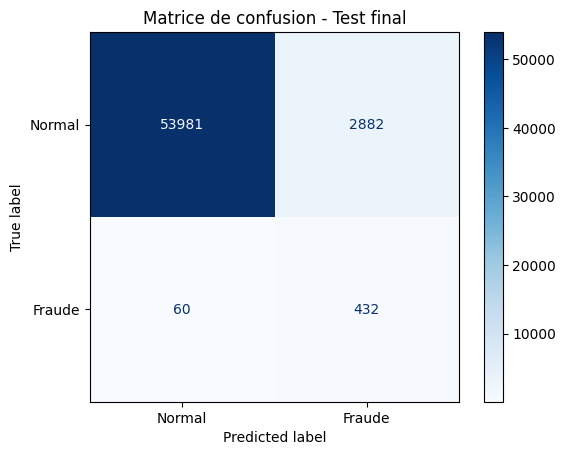

In [34]:
# METRIQUES VALIDATION + TEST FINAL

# Validation (normaux uniquement)
accuracy_val = np.mean(y_pred_val == y_val)
fp_rate_val = np.mean(y_pred_val == -1)

print("\n[Validation]")
print(f"  Accuracy (normaux)        : {accuracy_val:.4f}")
print(f"  Faux positifs validation  : {fp_rate_val:.4f} ({fp_rate_val*100:.1f}%)")
print(f"  Score decision moyen      : {decision_scores_val.mean():.4f}")

# Test final (normaux + fraudes)
accuracy_test = np.mean(y_pred_test == y_test)
mask_fraud = y_test == -1
mask_normal = y_test == 1
recall_fraud = np.mean(y_pred_test[mask_fraud] == -1)
fp_rate = np.mean(y_pred_test[mask_normal] == -1)

print("\n[Test Final]")
print(f"  Accuracy globale          : {accuracy_test:.4f}")
print(f"  Recall fraudes            : {recall_fraud:.4f} ({recall_fraud*100:.1f}%)")
print(f"  Taux de faux positifs     : {fp_rate:.4f} ({fp_rate*100:.1f}%)")
print(f"  Score decision moyen      : {decision_scores_test.mean():.4f}")

print("\n[Rapport de classification - Test Final]")
print(classification_report(
    y_test, y_pred_test,
    labels=[1, -1],
    target_names=["Normal", "Fraude"]
))

# Matrice de confusion sur test final
cm = confusion_matrix(y_test, y_pred_test, labels=[1, -1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Fraude"])
disp.plot(cmap="Blues")
plt.title("Matrice de confusion - Test final")
plt.show()